In [1]:
%matplotlib inline
%config InlineBackend.figure_format = 'retina'
import matplotlib.pyplot as plt
import numpy as np

In [2]:
import sys
sys.path.append('../')
from CEmulator.Emulator import CBaseEmulator

Omegab = 0.055
Omegam = 0.353
H0     = 63.6
ns     = 0.964
sigma8 = 0.781
mnu    = 0.06  # One single massive neutrino with two massless neutrinos
w      = -0.42
wa     = -1.75
Omegan = mnu/93.14/H0**2 * 1e4
Omegacb  = round(Omegam-Omegan, 8)
Omegac   = Omegacb - Omegab
print(Omegacb, Omegac)

csstemu = CBaseEmulator(verbose=True)
zlists  = np.array([0.0, 1.0, 2.0, 3.0])
##### need extra package [CLASS/CAMB] to transform sigma8 to As
csstemu.set_cosmos(Omegab=Omegab, Omegac=Omegac, H0=H0, sigma8=sigma8, ns=ns, 
                   w=w, wa=wa, mnu=mnu, checkbound=False, sigma8type='CLASS')
As = csstemu.Cosmo.As
print(As)

0.35140742 0.29640742000000003
Loading the PkcbLin emulator...
Using 513 training samples.
Loading the PknnLin emulator...
Using 512 training samples [remove c0001 (no massive neutrino)].
The neutrino mass is treated as a single massive component.
The As is set to 2.082799e-09 (sigma8=0.781000) to match the input sigma8=0.781000.
2.0827988478868847e-09


# First condition: find weq or (w0,wa)eq

In [13]:
%%time
#First, obtain the equivalent w0, wa for the original cosmology
from CEmulator.SpectralEquivalence import SpectralEquivalence_DE

w0_arr, wa_arr = SpectralEquivalence_DE(csstemu, zlists, wCDM=False)
print(w0_arr)
print(wa_arr)

[-0.73511235 -0.86680165 -0.97378363 -1.04211815]
[-0.5 -0.5 -0.5 -0.5]
CPU times: user 1.09 s, sys: 926 µs, total: 1.1 s
Wall time: 1.1 s


In [14]:
%%time
wconst_arr = SpectralEquivalence_DE(csstemu, zlists, wCDM=True)
print(wconst_arr)

[-0.87456146 -1.0526786  -1.19982048 -1.29430299]
CPU times: user 114 ms, sys: 0 ns, total: 114 ms
Wall time: 114 ms


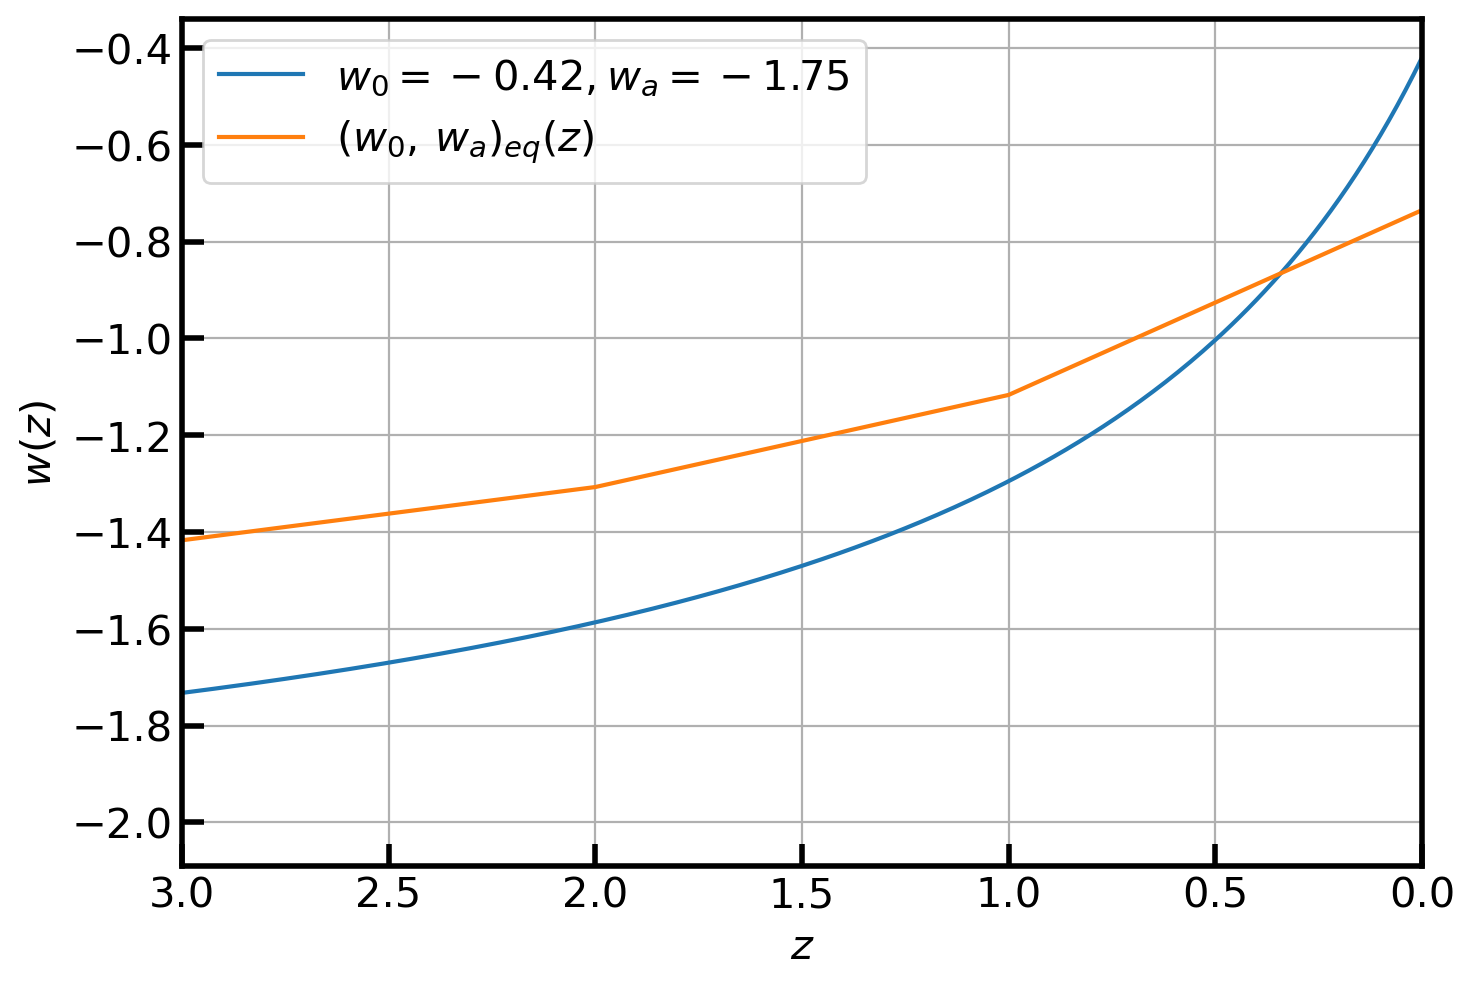

In [5]:
ztt = np.linspace(0, 10, 1000)
with plt.style.context('article'):
    plt.plot(ztt, (w+wa*ztt/(1+ztt)), label=r"$w_0=%.2f, w_a=%.2f$"%(w, wa))
    plt.plot(zlists, (w0_arr + wa_arr*zlists/(1+zlists)), label=r"$(w_0,\, w_a)_{eq}(z)$")
    plt.xlim(3, 0)
    plt.grid(True)
    plt.legend()
    plt.xlabel(r'$z$')
    plt.ylabel(r"$w(z)$")

### neutrino_matter_like option

The neutrino_matter_like option allows you to treat neutrinos as matter in the background evolution. This can accelerate the calculation of comoving distance, leading to shorter time of the finding of equivalent dark energy models [i.e., $w_{\rm eq}$ or $(w_{0}, w_{a})_{\rm eq}$].

This approximation should be used with caution, as it may not be accurate for all cosmological models, especially those with significant neutrino contributions. It is recommended to compare the results obtained with this option against more accurate methods to ensure the validity of the approximation in your specific case.

In [6]:
from CEmulator.SpectralEquivalence import SpectralEquivalence_DE

In [7]:
%%time
wconst_arr = SpectralEquivalence_DE(csstemu, [0.5], wCDM=True, method="finite_diff_newton")
print(wconst_arr)

[-0.95316006]
CPU times: user 41.2 ms, sys: 964 µs, total: 42.2 ms
Wall time: 41.9 ms


In [8]:
%%time
wconst_arr = SpectralEquivalence_DE(csstemu, [0.5], wCDM=True, method="newton", neutrino_matter_like=False)
print(wconst_arr)

[-0.95316006]
CPU times: user 26.5 ms, sys: 966 µs, total: 27.5 ms
Wall time: 27.2 ms


In [9]:
%time
wconst_arr = SpectralEquivalence_DE(csstemu, [0.5], wCDM=True, method="newton", neutrino_matter_like=True)
print(wconst_arr)

CPU times: user 2 µs, sys: 0 ns, total: 2 µs
Wall time: 4.53 µs
[-0.95315937]


In [10]:
%%time
w0_arr, wa_arr = SpectralEquivalence_DE(csstemu, [0.5], wCDM=False, neutrino_matter_like=False)
print(w0_arr, wa_arr)

[-0.79373412] [-0.5]
CPU times: user 435 ms, sys: 953 µs, total: 436 ms
Wall time: 436 ms


In [11]:
%%time
w0_arr, wa_arr = SpectralEquivalence_DE(csstemu, [0.5], wCDM=False, neutrino_matter_like=True)
print(w0_arr, wa_arr)

[-0.79373355] [-0.5]
CPU times: user 213 ms, sys: 1.62 ms, total: 215 ms
Wall time: 214 ms


# Second condition: find As or sigma8

In [15]:
%%time
# Then, obtain the equivalent As for the original cosmology
from CEmulator.SpectralEquivalence import SpectralEquivalence_As

Aseq_arr = SpectralEquivalence_As(csstemu, zlists, w0_arr, wa_arr, sigma8_type='CLASS')
print(As * 1e9)
print(Aseq_arr * 1e9)

2.0827988478868846
[2.10777089 2.08600854 2.08120037 2.08072027]
CPU times: user 2.93 s, sys: 42.5 ms, total: 2.97 s
Wall time: 2.98 s


In [16]:
%%time
# Then, obtain the equivalent As for the original cosmology
from CEmulator.SpectralEquivalence import SpectralEquivalence_As

Aseq_arr = SpectralEquivalence_As(csstemu, zlists, w0_arr, wa_arr, sigma8_type='CAMB')
print(As * 1e9)
print(Aseq_arr * 1e9)

2.0827988478868846
[2.10960195 2.08777267 2.08292485 2.08242087]
CPU times: user 7.74 s, sys: 56.9 ms, total: 7.8 s
Wall time: 8.24 s
